# Assignment 2: Recreate a Paper
## Sharp transition towards shared vocabularies in multi-agent systems

In [1]:
import mesa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import itertools # use this if needed
import string

/home/vincent/Desktop/School/Graz/S_2026/CMSS/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Our understanding of the model:

We have

In [2]:
WORD_LENGTH = 5

In [3]:
def num_total_words(model):
    total_count = 0
    for agent in model.agents:
        for obj in agent.vocabulary:
            total_count += len(agent.vocabulary[obj])
    return total_count

def num_unique_words(model):
    unique_words = set()
    for agent in model.agents:
        for obj in agent.vocabulary:
            unique_words.update(agent.vocabulary[obj])
    return len(unique_words)

In [4]:
class PlayerAgent(mesa.Agent):
    def __init__(self, model: mesa.Model, *args, **kwargs) -> None:
        super().__init__(model, *args, **kwargs)

        self.vocabulary = dict()

    def generate_new_word(self):
        new_word = "".join(random.choices(string.ascii_letters, k=WORD_LENGTH))

        return new_word

    def speak(self,context):
        current_object = random.choice(context)
        if current_object not in self.vocabulary:
            new_word = self.generate_new_word()
            self.vocabulary[current_object] = [new_word]
            return (current_object, new_word)
        else:
            return (current_object, random.choice(self.vocabulary[current_object]))

    def hear(self,word,current_object):
        #If the agent doesn't have any words in the vocabulary associated with the object
        if current_object not in self.vocabulary:
            self.vocabulary[current_object] = [word]
            return False
        #If the agent already has words in its vocabulary for the object, but none of them match
        elif word not in self.vocabulary[current_object]:
            self.vocabulary[current_object].append(word)
            return False
        # If one of the words in the vocabulary matches the heard word
        else:
            self.vocabulary[current_object] = [word]
            return True

In [80]:
class Object():
    pass

class NamingGame(mesa.Model):
    def __init__(self, n_players: int, n_rounds: int, n_objects: int = 1):
        """This implements the naming game with a variable number of agents, rounds and objects to name"""
        super().__init__()
        self.n_agents = n_players
        self.n_rounds = n_rounds
        self.n_objects = n_objects
        self.objects = []
        self.interaction_results = None

        for _ in range(n_objects):
            self.objects.append(Object())

        for _ in range(self.n_agents):
          PlayerAgent(self)

        self.datacollector = mesa.DataCollector(
            {
                "all_words": num_total_words,
                "unique_words": num_unique_words,
                "success": self.get_interaction_results
            }
        )

    def step(self):
        self.agents.shuffle(inplace=True)
        speaker, hearer = self.agents.select(at_most=2)
        # print(f"Speaker vocab: {speaker.vocabulary}")
        # print(f"Hearer vocab: {hearer.vocabulary}")
        curr_object, word = speaker.speak(self.objects)
        # print(f"Speaker vocab after speaking: {speaker.vocabulary}")
        success = hearer.hear(word, curr_object)
        # print(f"Hearer vocab after hearing: {hearer.vocabulary}")
        # print("----------------------------------------------")
        self.interaction_results = success
        self.datacollector.collect(self)

        #Logic to turn off at convergence
        if (num_unique_words(self) == len(self.objects)) and (num_total_words(self) == len(self.objects) * self.n_agents):
            print("Done")
            self.running = False
        # self.running = True if self.n_rounds == None or self.steps < self.n_rounds else False


    def get_interaction_results(self):
        return self.interaction_results

In [119]:
model = NamingGame(1000, None, 1)
model.run_model()

Done


In [120]:
data = model.datacollector.get_model_vars_dataframe()

In [121]:
data['success'].mean()

np.float64(0.2597861355753401)

<Axes: ylabel='unique_words'>

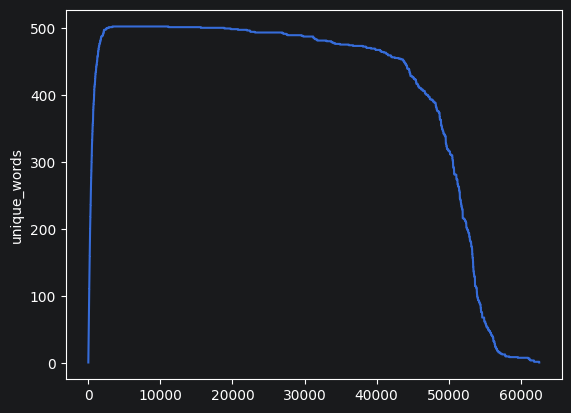

In [122]:
sns.lineplot(data['unique_words'])

<Axes: ylabel='all_words'>

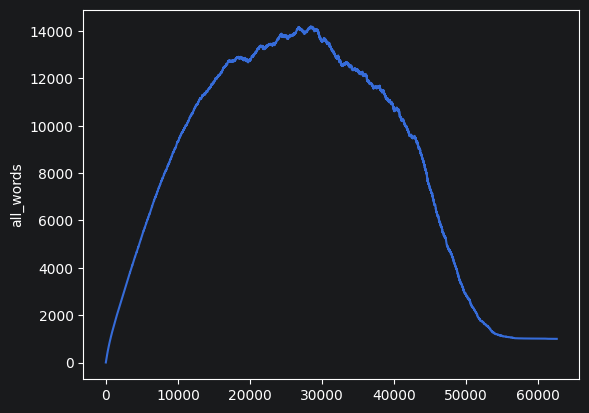

In [123]:
sns.lineplot(data['all_words'])